In [1]:
import numpy as np
from scipy.io import readsav
from datetime import datetime, timedelta
import scipy.integrate as integrate
from scipy.integrate import simpson as simp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.dates as mdates
import pdb
from scipy.io import loadmat  # but fname_sou = 'alphacen_all_visits.mat'
from scipy.io import savemat, loadmat
from scipy.io import readsav
import numpy as np

['dates_ab', 'sun_mgii_on_ab_dates_original', 'sun_mgii_on_ab_dates_shifted', 'dates_a', 'alphaA_merged_original', 'alphaA_merged_shifted', 'dates_b', 'alphaB_merged_original', 'alphaB_merged_shifted']


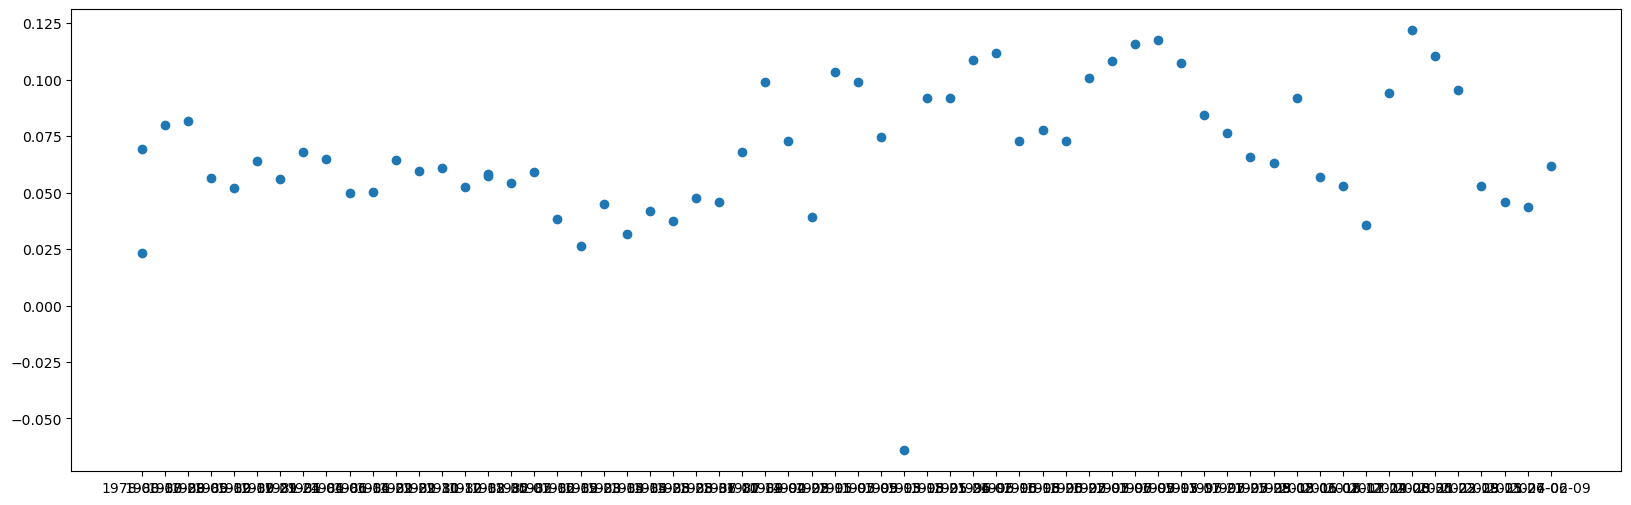

In [2]:
new_data = np.load('/Users/soumit/Downloads/alpha_cen_stuff/alphaCenAB_mgII_timeseries.npz', allow_pickle=True)


print(new_data.files)

alphaB_merge = new_data['alphaB_merged_shifted']
dates_b = new_data['dates_b']

plt.figure(figsize=(20, 6))
plt.scatter(dates_b, alphaB_merge)


Best period (days): 2914.3859649122805
Best period (years): 7.979153908041836


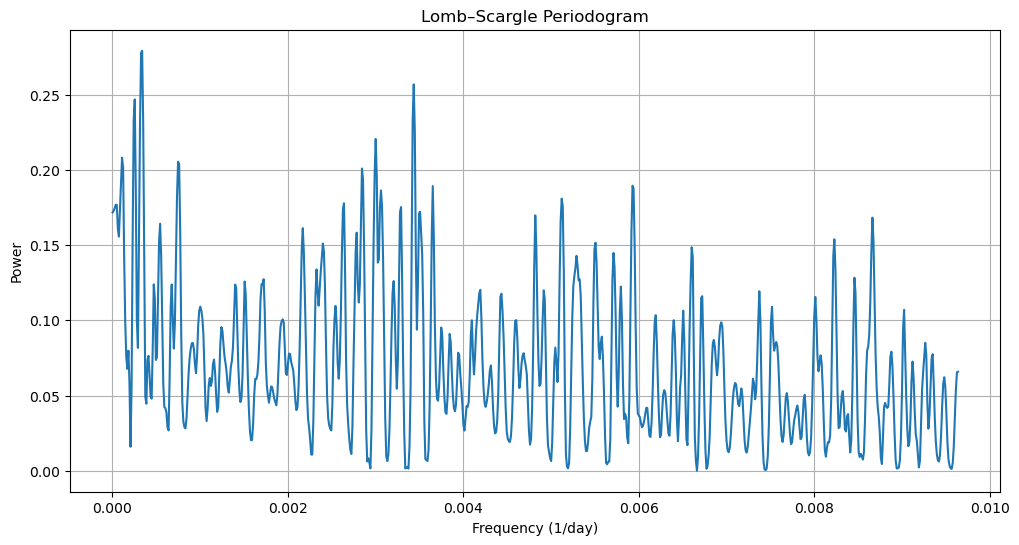

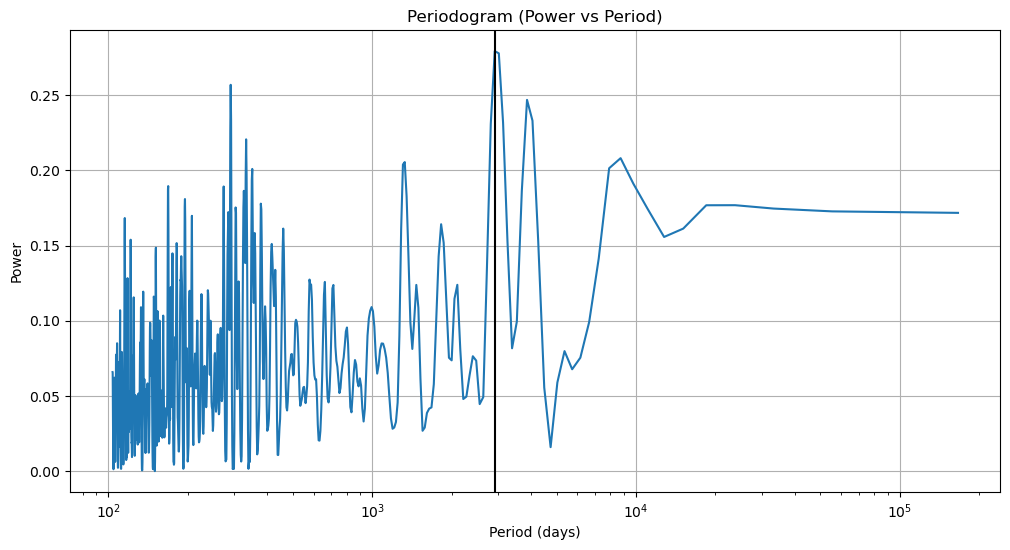

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

# convert date strings → numerical days
t_datetime = np.array(dates_b, dtype='datetime64[D]')
t_days = (t_datetime - t_datetime[0]).astype('timedelta64[D]').astype(float)

# y-values
y = np.array(alphaB_merge, dtype=float)

# lomb–scargle
frequency, power = LombScargle(t_days, y).autopower()

# best period
best_frequency = frequency[np.argmax(power)]
best_period = 1 / best_frequency

print("Best period (days):", best_period)
print("Best period (years):", best_period / 365.25)

# plot frequency-domain
plt.figure(figsize=(12, 6))
plt.plot(frequency, power)
plt.xlabel("Frequency (1/day)")
plt.ylabel("Power")
plt.title("Lomb–Scargle Periodogram")
plt.grid(True)
plt.show()

# plot period-domain
period = 1 / frequency
plt.figure(figsize=(12, 6))
plt.plot(period, power)
plt.xscale("log")
plt.xlabel("Period (days)")
plt.axvline(best_period, color = 'black')
plt.ylabel("Power")
plt.title("Periodogram (Power vs Period)")
plt.grid(True)
plt.show()


Alpha Cen A (shifted) best period (days): 122.49
Alpha Cen A (shifted) best period (years): 0.34
--------------------------------------------------


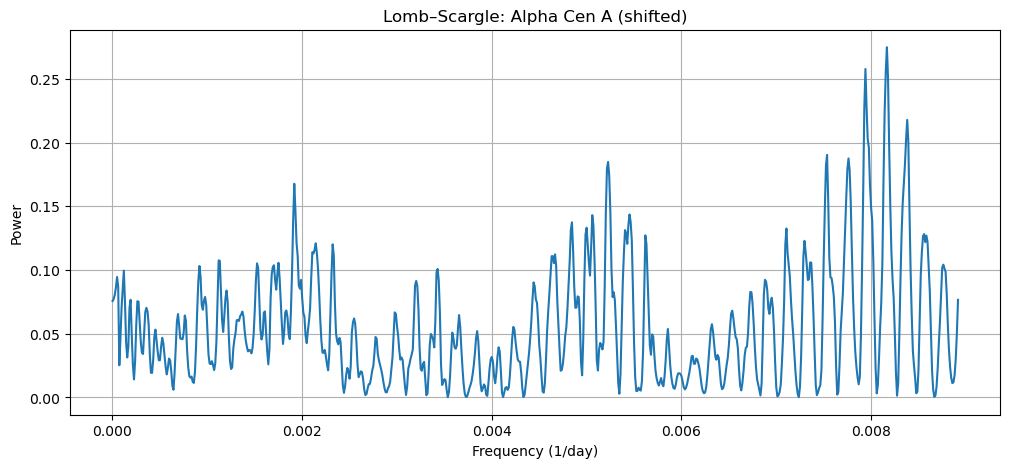

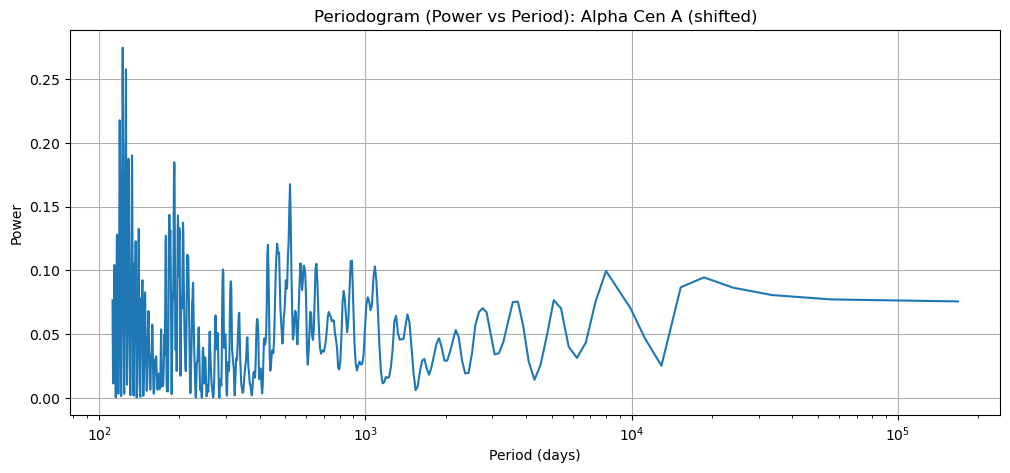

Alpha Cen B (shifted) best period (days): 2914.39
Alpha Cen B (shifted) best period (years): 7.98
--------------------------------------------------


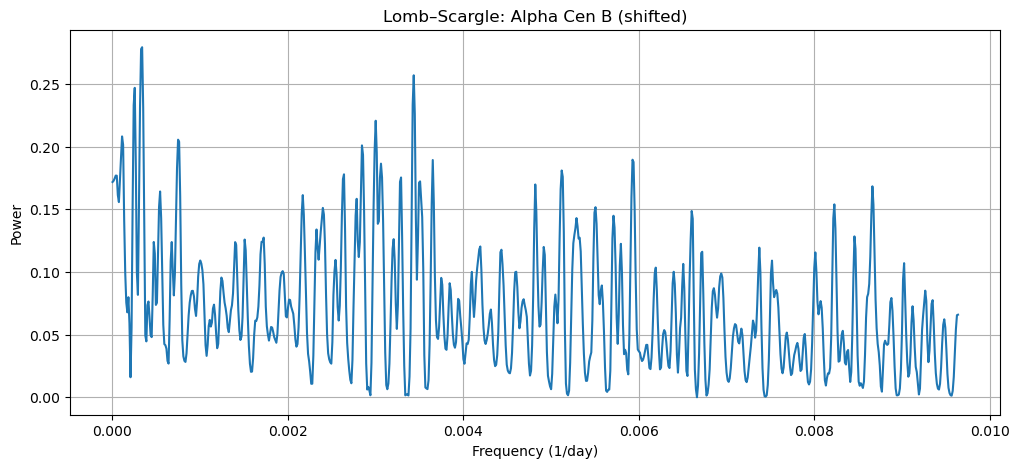

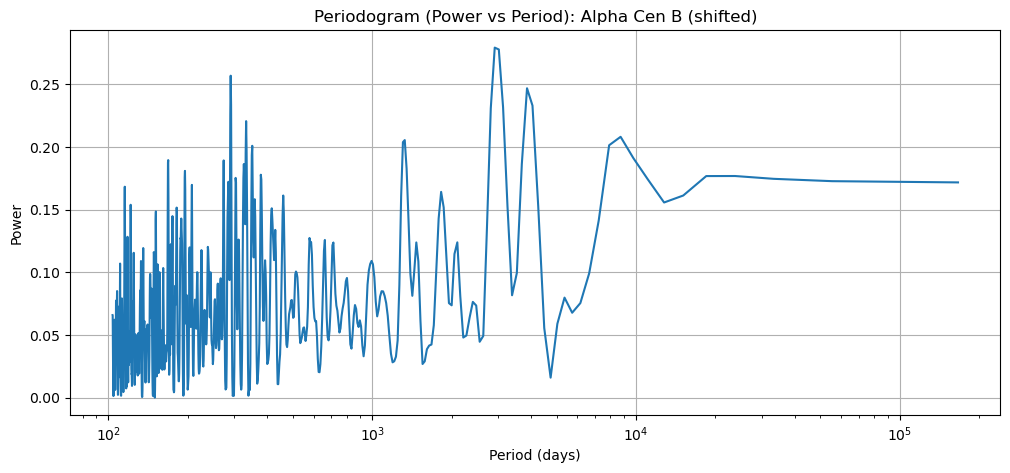

Alpha Cen A+B (Sun on merged dates) best period (days): 3911.16
Alpha Cen A+B (Sun on merged dates) best period (years): 10.71
--------------------------------------------------


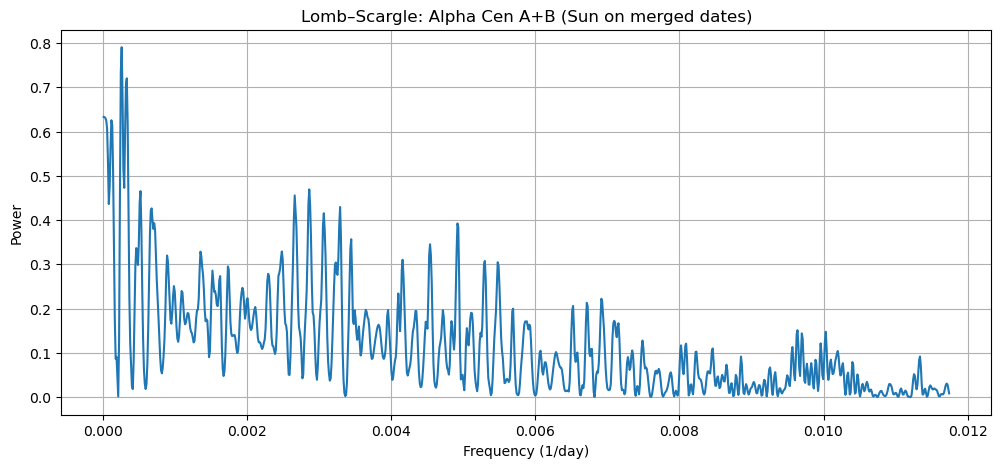

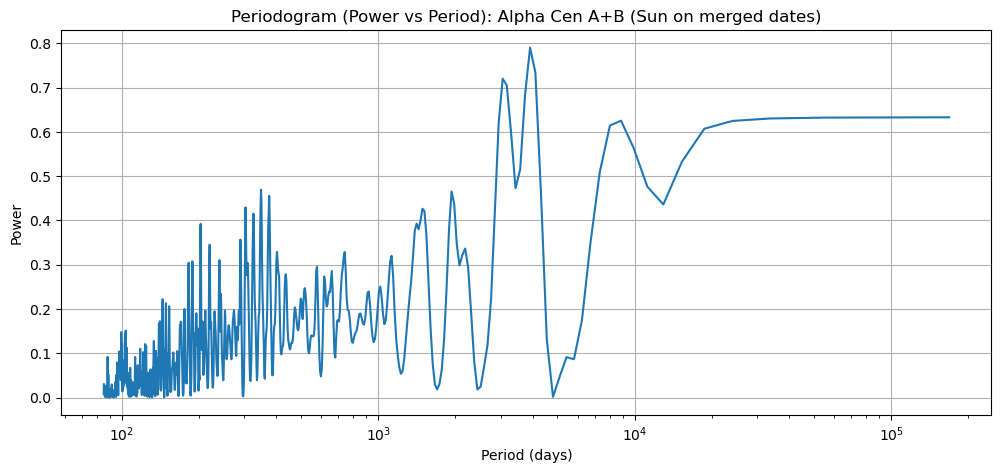

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

# ----------------------------
# Helper: convert YYYY-MM-DD → float days
# ----------------------------
def convert_dates_to_days(date_array):
    t_dt = np.array(date_array, dtype='datetime64[D]')
    return (t_dt - t_dt[0]).astype('timedelta64[D]').astype(float)

# ----------------------------
# Load shifted datasets
# ----------------------------
dates_a = new_data['dates_a']
dates_b = new_data['dates_b']
dates_ab = new_data['dates_ab']

alphaA = new_data['alphaA_merged_shifted']
alphaB = new_data['alphaB_merged_shifted']
alphaAB = new_data['sun_mgii_on_ab_dates_shifted']

# ----------------------------
# Convert dates → days
# ----------------------------
t_a = convert_dates_to_days(dates_a)
t_b = convert_dates_to_days(dates_b)
t_ab = convert_dates_to_days(dates_ab)

# ----------------------------
# Lomb–Scargle function
# ----------------------------
def do_lomb_scargle(t, y, label):
    mask = ~np.isnan(y)
    t = t[mask]
    y = y[mask].astype(float)
    
    frequency, power = LombScargle(t, y).autopower()
    period = 1 / frequency

    # best period
    best_freq = frequency[np.argmax(power)]
    best_period = 1 / best_freq

    print(f"{label} best period (days): {best_period:.2f}")
    print(f"{label} best period (years): {best_period/365.25:.2f}")
    print("-" * 50)

    # --- frequency-domain plot ---
    plt.figure(figsize=(12,5))
    plt.plot(frequency, power)
    plt.xlabel("Frequency (1/day)")
    plt.ylabel("Power")
    plt.title(f"Lomb–Scargle: {label}")
    plt.grid(True)
    plt.show()

    # --- period-domain plot ---
    plt.figure(figsize=(12,5))
    plt.plot(period, power)
    plt.xscale("log")
    plt.xlabel("Period (days)")
    plt.ylabel("Power")
    plt.title(f"Periodogram (Power vs Period): {label}")
    plt.grid(True)
    plt.show()

# ----------------------------
# Run LS for A, B, and AB
# ----------------------------
do_lomb_scargle(t_a, alphaA, "Alpha Cen A (shifted)")
do_lomb_scargle(t_b, alphaB, "Alpha Cen B (shifted)")
do_lomb_scargle(t_ab, alphaAB, "Alpha Cen A+B (Sun on merged dates)")


SUN best period (days): 3911.162790697674
SUN best period (years): 10.708180125113413


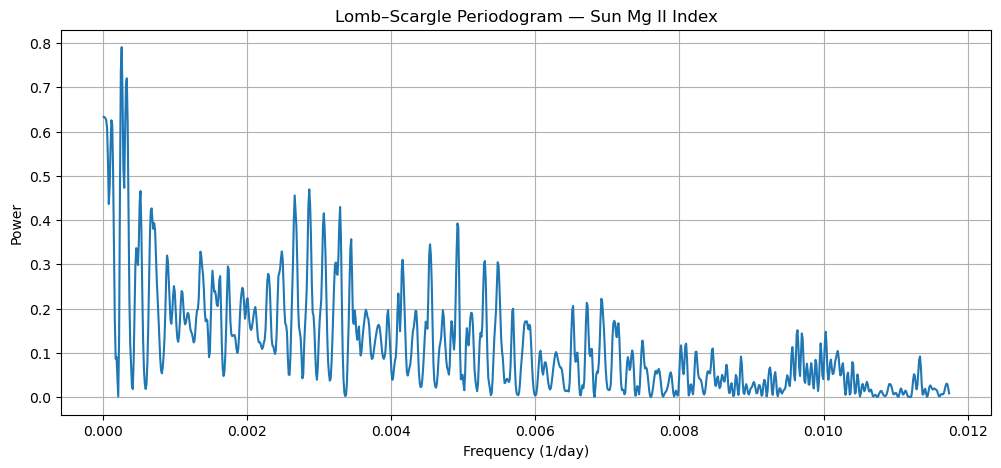

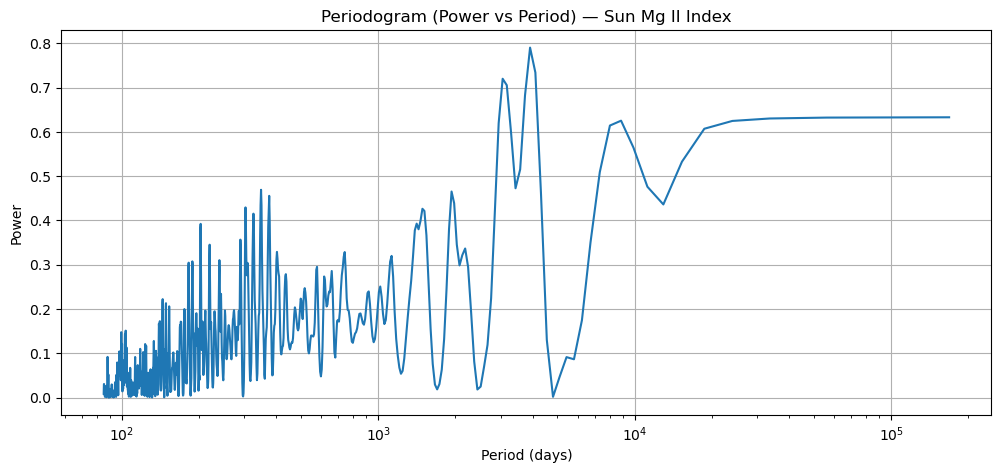

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

# --- load Sun data ---
dates_sun = new_data['dates_ab']                     # dates for A+B merged
sun_mgii = new_data['sun_mgii_on_ab_dates_shifted']  # Sun's Mg II index

# --- convert dates to float days ---
t_dt = np.array(dates_sun, dtype='datetime64[D]')
t_sun = (t_dt - t_dt[0]).astype('timedelta64[D]').astype(float)

# --- clean NaNs ---
mask = ~np.isnan(sun_mgii)
t_sun = t_sun[mask]
y_sun = sun_mgii[mask].astype(float)

# --- Lomb–Scargle ---
frequency, power = LombScargle(t_sun, y_sun).autopower()
period = 1 / frequency

# --- best period ---
best_frequency = frequency[np.argmax(power)]
best_period = 1 / best_frequency

print("SUN best period (days):", best_period)
print("SUN best period (years):", best_period / 365.25)

# --- plot (frequency domain) ---
plt.figure(figsize=(12,5))
plt.plot(frequency, power)
plt.xlabel("Frequency (1/day)")
plt.ylabel("Power")
plt.title("Lomb–Scargle Periodogram — Sun Mg II Index")
plt.grid(True)
plt.show()

# --- plot (period domain) ---
plt.figure(figsize=(12,5))
plt.plot(period, power)
plt.xscale('log')
plt.xlabel("Period (days)")
plt.ylabel("Power")
plt.title("Periodogram (Power vs Period) — Sun Mg II Index")
plt.grid(True)
plt.show()


Alpha Cen A best period (days): 7877.876883616544
Alpha Cen A best period (years): 21.56845142673934


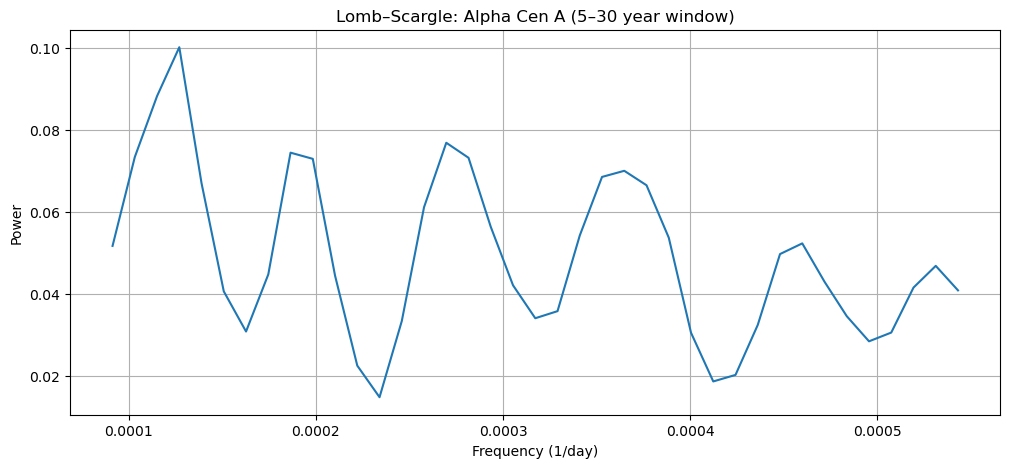

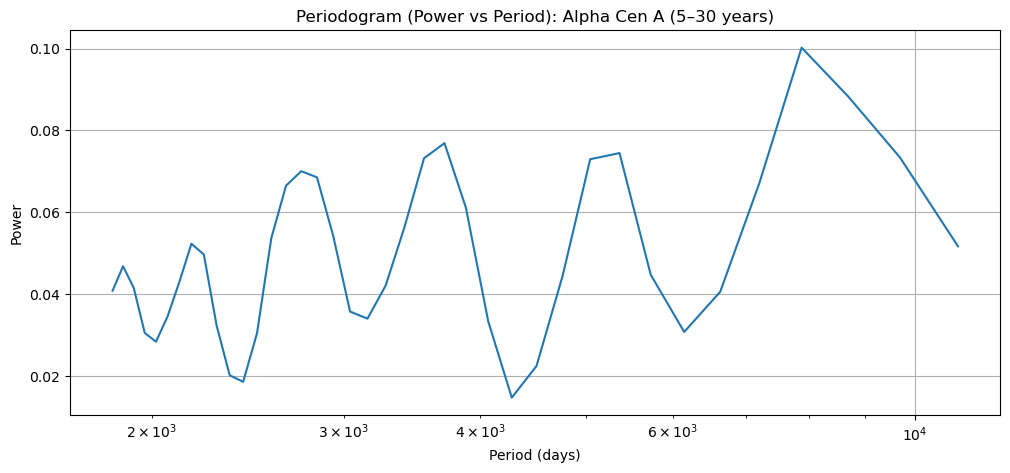

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

# --- extract Alpha Cen A ---
alphaA = new_data['alphaA_merged_shifted']
dates_a = new_data['dates_a']

# --- convert dates to float days ---
t_dt = np.array(dates_a, dtype='datetime64[D]')
t_a = (t_dt - t_dt[0]).astype('timedelta64[D]').astype(float)

# --- clean NaNs ---
mask = ~np.isnan(alphaA)
t = t_a[mask]
y = alphaA[mask].astype(float)

# --- 5–30 year period range ---
period_min = 5 * 365.25       # days
period_max = 30 * 365.25      # days

freq_min = 1 / period_max
freq_max = 1 / period_min

# --- Lomb–Scargle ---
frequency, power = LombScargle(t, y).autopower(
    minimum_frequency=freq_min,
    maximum_frequency=freq_max
)

period = 1 / frequency

# --- best period ---
best_frequency = frequency[np.argmax(power)]
best_period = 1 / best_frequency

print("Alpha Cen A best period (days):", best_period)
print("Alpha Cen A best period (years):", best_period / 365.25)

# --- plot: frequency-domain ---
plt.figure(figsize=(12, 5))
plt.plot(frequency, power)
plt.xlabel("Frequency (1/day)")
plt.ylabel("Power")
plt.title("Lomb–Scargle: Alpha Cen A (5–30 year window)")
plt.grid(True)
plt.show()

# --- plot: period-domain ---
plt.figure(figsize=(12, 5))
plt.plot(period, power)
plt.xscale("log")
plt.xlabel("Period (days)")
plt.ylabel("Power")
plt.title("Periodogram (Power vs Period): Alpha Cen A (5–30 years)")
plt.grid(True)
plt.show()


## visit 1

In [7]:
alpha_visit_1 = np.load('/Users/soumit/Downloads/alpha_cen_stuff/cute/alpha_cen_visit1_2025_fluxes.npz' , allow_pickle= True)

print(alpha_visit_1)

phot1_vis1 = alpha_visit_1['phot1_vis1']
phot2_vis1 = alpha_visit_1['phot2_vis1']
chrom_vis1 = alpha_visit_1['chrom_vis1']
dates_vis1 = alpha_visit_1['dates_vis1']

print(dates_vis1)


# assume your array is called "dt_array"
dt_vis_1 = np.array(dates_vis1)   # ensure numpy array of datetime objects

# convert to float days relative to first timestamp
t_days_1 = np.array([(dt - dt_vis_1[0]).total_seconds() / 86400.0 for dt in dt_vis_1])

print(t_days_1)

NpzFile '/Users/soumit/Downloads/alpha_cen_stuff/cute/alpha_cen_visit1_2025_fluxes.npz' with keys: phot1_vis1, phot2_vis1, chrom_vis1, dates_vis1
[datetime.datetime(2025, 4, 27, 5, 46, 51)
 datetime.datetime(2025, 4, 27, 5, 57, 1)
 datetime.datetime(2025, 4, 27, 6, 2, 6)
 datetime.datetime(2025, 4, 27, 7, 20, 6)
 datetime.datetime(2025, 4, 27, 7, 30, 16)
 datetime.datetime(2025, 4, 27, 7, 35, 21)
 datetime.datetime(2025, 4, 27, 8, 53, 21)
 datetime.datetime(2025, 4, 27, 9, 3, 31)
 datetime.datetime(2025, 4, 27, 9, 8, 36)
 datetime.datetime(2025, 4, 27, 10, 26, 36)
 datetime.datetime(2025, 4, 27, 10, 36, 46)
 datetime.datetime(2025, 4, 27, 10, 41, 51)
 datetime.datetime(2025, 4, 27, 11, 59, 51)
 datetime.datetime(2025, 4, 27, 12, 10, 1)
 datetime.datetime(2025, 4, 27, 12, 15, 6)]
[0.         0.00706019 0.01059028 0.06475694 0.07181713 0.07534722
 0.12951389 0.13657407 0.14010417 0.19427083 0.20133102 0.20486111
 0.25902778 0.26608796 0.26961806]


5.587142153934956e-08


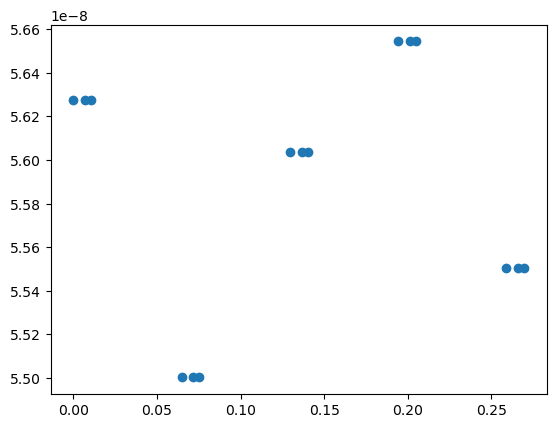

In [8]:
plt.scatter(t_days_1 , phot1_vis1)

print(np.average(phot1_vis1))



## visit 2

In [9]:
alpha_visit_2 = np.load('/Users/soumit/Downloads/alpha_cen_stuff/cute/alpha_cen_visit2_2025_fluxes.npz' , allow_pickle= True)

print(alpha_visit_2)

phot1_vis2 = alpha_visit_2['phot1_vis2']
phot2_vis2 = alpha_visit_2['phot2_vis2']
chrom_vis2 = alpha_visit_2['chrom_vis2']
dates_vis2 = alpha_visit_2['dates_vis2']

print(dates_vis2)


# assume your array is called "dt_array"
dt_vis_2 = np.array(dates_vis2)   # ensure numpy array of datetime objects

# convert to float days relative to first timestamp
t_days_2 = np.array([(dt - dt_vis_2[0]).total_seconds() / 86400.0 for dt in dt_vis_2])

print(t_days_2)

NpzFile '/Users/soumit/Downloads/alpha_cen_stuff/cute/alpha_cen_visit2_2025_fluxes.npz' with keys: phot1_vis2, phot2_vis2, chrom_vis2, dates_vis2
[datetime.datetime(2025, 5, 4, 5, 36, 31)
 datetime.datetime(2025, 5, 4, 5, 46, 41)
 datetime.datetime(2025, 5, 4, 5, 51, 46)
 datetime.datetime(2025, 5, 4, 7, 9, 46)
 datetime.datetime(2025, 5, 4, 7, 19, 56)
 datetime.datetime(2025, 5, 4, 7, 25, 1)
 datetime.datetime(2025, 5, 4, 8, 42, 56)
 datetime.datetime(2025, 5, 4, 8, 53, 6)
 datetime.datetime(2025, 5, 4, 8, 58, 11)
 datetime.datetime(2025, 5, 4, 10, 16, 11)
 datetime.datetime(2025, 5, 4, 10, 26, 21)
 datetime.datetime(2025, 5, 4, 10, 31, 26)
 datetime.datetime(2025, 5, 4, 11, 49, 26)
 datetime.datetime(2025, 5, 4, 11, 59, 36)
 datetime.datetime(2025, 5, 4, 12, 4, 41)]
[0.         0.00706019 0.01059028 0.06475694 0.07181713 0.07534722
 0.12945602 0.1365162  0.1400463  0.19421296 0.20127315 0.20480324
 0.25896991 0.26603009 0.26956019]


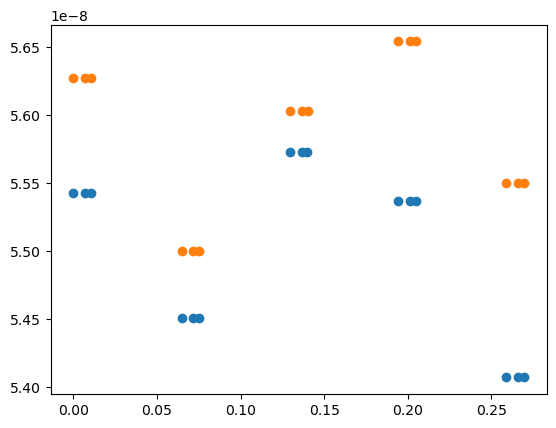

In [10]:
plt.scatter(t_days_2 , phot1_vis2)
plt.scatter(t_days_1 , phot1_vis1)

avg_phot1_vis2 = np.average(phot1_vis2)



In [11]:
# print(avg_phot1_vis1 - avg_phot1_vis2  )

## visit 3

In [12]:
alpha_visit_3 = np.load('/Users/soumit/Downloads/alpha_cen_stuff/cute/alpha_cen_visit3_2025_fluxes.npz' , allow_pickle= True)

print(alpha_visit_3)

phot1_vis3 = alpha_visit_3['phot1_vis3']
phot2_vis3 = alpha_visit_3['phot2_vis3']
chrom_vis3 = alpha_visit_3['chrom_vis3']
dates_vis3 = alpha_visit_3['dates_vis3']

print(dates_vis3)


# assume your array is called "dt_array"
dt_vis_3 = np.array(dates_vis3)   # ensure numpy array of datetime objects

# convert to float days relative to first timestamp
t_days_3 = np.array([(dt - dt_vis_3[0]).total_seconds() / 86400.0 for dt in dt_vis_3])

print(t_days_3)

NpzFile '/Users/soumit/Downloads/alpha_cen_stuff/cute/alpha_cen_visit3_2025_fluxes.npz' with keys: phot1_vis3, phot2_vis3, chrom_vis3, dates_vis3
[datetime.datetime(2025, 5, 11, 6, 57, 51)
 datetime.datetime(2025, 5, 11, 7, 8, 1)
 datetime.datetime(2025, 5, 11, 7, 13, 6)
 datetime.datetime(2025, 5, 11, 8, 31, 6)
 datetime.datetime(2025, 5, 11, 8, 41, 16)
 datetime.datetime(2025, 5, 11, 8, 46, 21)
 datetime.datetime(2025, 5, 11, 10, 4, 16)
 datetime.datetime(2025, 5, 11, 10, 14, 26)
 datetime.datetime(2025, 5, 11, 10, 19, 31)
 datetime.datetime(2025, 5, 11, 11, 37, 31)
 datetime.datetime(2025, 5, 11, 11, 47, 41)
 datetime.datetime(2025, 5, 11, 11, 52, 46)
 datetime.datetime(2025, 5, 11, 13, 10, 41)
 datetime.datetime(2025, 5, 11, 13, 20, 51)
 datetime.datetime(2025, 5, 11, 13, 25, 56)]
[0.         0.00706019 0.01059028 0.06475694 0.07181713 0.07534722
 0.12945602 0.1365162  0.1400463  0.19421296 0.20127315 0.20480324
 0.25891204 0.26597222 0.26950231]


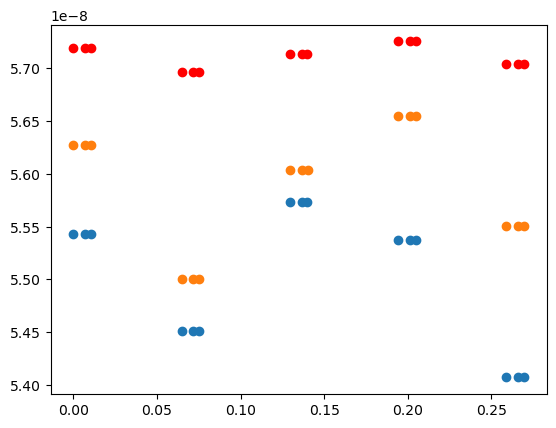

In [13]:
plt.scatter(t_days_3 , phot1_vis3 , color ='red')
plt.scatter(t_days_2 , phot1_vis2)
plt.scatter(t_days_1 , phot1_vis1)

avg_phot1_vis3 = np.average(phot1_vis3)



## visit 4

NpzFile '/Users/soumit/Downloads/alpha_cen_stuff/cute/alpha_cen_visit4_2025_fluxes.npz' with keys: phot1_vis4, phot2_vis4, chrom_vis4, dates_vis4
[datetime.datetime(2025, 5, 18, 6, 43, 36)
 datetime.datetime(2025, 5, 18, 6, 53, 46)
 datetime.datetime(2025, 5, 18, 6, 58, 51)
 datetime.datetime(2025, 5, 18, 8, 16, 46)
 datetime.datetime(2025, 5, 18, 8, 26, 56)
 datetime.datetime(2025, 5, 18, 8, 32, 1)
 datetime.datetime(2025, 5, 18, 9, 50, 1)
 datetime.datetime(2025, 5, 18, 10, 0, 11)
 datetime.datetime(2025, 5, 18, 10, 5, 16)
 datetime.datetime(2025, 5, 18, 11, 23, 11)
 datetime.datetime(2025, 5, 18, 11, 33, 21)
 datetime.datetime(2025, 5, 18, 11, 38, 26)
 datetime.datetime(2025, 5, 18, 12, 56, 26)
 datetime.datetime(2025, 5, 18, 13, 6, 36)
 datetime.datetime(2025, 5, 18, 13, 11, 41)]
[0.         0.00706019 0.01059028 0.06469907 0.07175926 0.07528935
 0.12945602 0.1365162  0.1400463  0.19415509 0.20121528 0.20474537
 0.25891204 0.26597222 0.26950231]


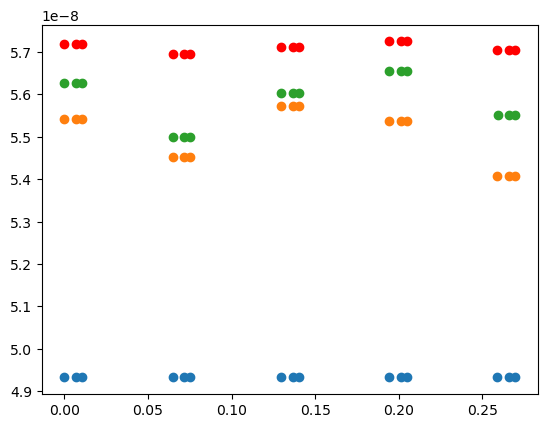

In [14]:
alpha_visit_4 = np.load('/Users/soumit/Downloads/alpha_cen_stuff/cute/alpha_cen_visit4_2025_fluxes.npz' , allow_pickle= True)

print(alpha_visit_4)

phot1_vis4 = alpha_visit_4['phot1_vis4']
phot2_vis4 = alpha_visit_4['phot2_vis4']
chrom_vis4 = alpha_visit_4['chrom_vis4']
dates_vis4 = alpha_visit_4['dates_vis4']

print(dates_vis4)


# assume your array is called "dt_array"
dt_vis_4 = np.array(dates_vis4)   # ensure numpy array of datetime objects

# convert to float days relative to first timestamp
t_days_4 = np.array([(dt - dt_vis_4[0]).total_seconds() / 86400.0 for dt in dt_vis_4])

print(t_days_4)


plt.scatter(t_days_4 , phot1_vis4)
plt.scatter(t_days_3 , phot1_vis3 , color ='red')
plt.scatter(t_days_2 , phot1_vis2)
plt.scatter(t_days_1 , phot1_vis1)

avg_phot1_vis4 = np.average(phot1_vis4)



## visit 5

NpzFile '/Users/soumit/Downloads/alpha_cen_stuff/cute/alpha_cen_visit5_2025_fluxes.npz' with keys: phot1_vis5, phot2_vis5, chrom_vis5, dates_vis5
[datetime.datetime(2025, 5, 25, 6, 27, 56)
 datetime.datetime(2025, 5, 25, 6, 38, 6)
 datetime.datetime(2025, 5, 25, 6, 43, 11)
 datetime.datetime(2025, 5, 25, 8, 1, 6)
 datetime.datetime(2025, 5, 25, 8, 11, 16)
 datetime.datetime(2025, 5, 25, 8, 16, 21)
 datetime.datetime(2025, 5, 25, 9, 34, 16)
 datetime.datetime(2025, 5, 25, 9, 44, 26)
 datetime.datetime(2025, 5, 25, 9, 49, 31)
 datetime.datetime(2025, 5, 25, 11, 7, 26)
 datetime.datetime(2025, 5, 25, 11, 17, 36)
 datetime.datetime(2025, 5, 25, 11, 22, 41)
 datetime.datetime(2025, 5, 25, 12, 40, 41)
 datetime.datetime(2025, 5, 25, 12, 50, 51)
 datetime.datetime(2025, 5, 25, 12, 55, 56)]
[0.         0.00706019 0.01059028 0.06469907 0.07175926 0.07528935
 0.12939815 0.13645833 0.13998843 0.19409722 0.20115741 0.2046875
 0.25885417 0.26591435 0.26944444]


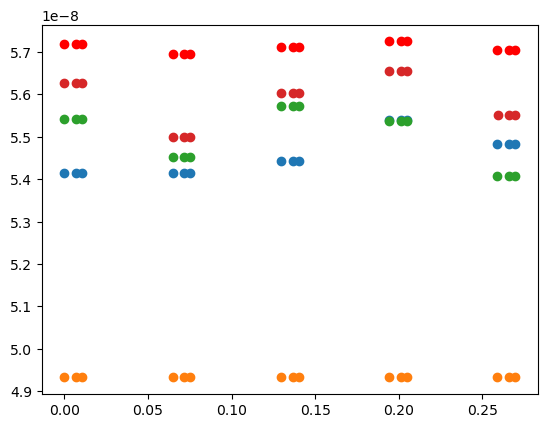

In [15]:
alpha_visit_5 = np.load('/Users/soumit/Downloads/alpha_cen_stuff/cute/alpha_cen_visit5_2025_fluxes.npz' , allow_pickle= True)

print(alpha_visit_5)

phot1_vis5 = alpha_visit_5['phot1_vis5']
phot2_vis5 = alpha_visit_5['phot2_vis5']
chrom_vis5 = alpha_visit_5['chrom_vis5']
dates_vis5 = alpha_visit_5['dates_vis5']

print(dates_vis5)


# assume your array is called "dt_array"
dt_vis_5 = np.array(dates_vis5)   # ensure numpy array of datetime objects

# convert to float days relative to first timestamp
t_days_5 = np.array([(dt - dt_vis_5[0]).total_seconds() / 86400.0 for dt in dt_vis_5])

print(t_days_5)


plt.scatter(t_days_5 , phot1_vis5)
plt.scatter(t_days_4 , phot1_vis4)
plt.scatter(t_days_3 , phot1_vis3 , color ='red')
plt.scatter(t_days_2 , phot1_vis2)
plt.scatter(t_days_1 , phot1_vis1)

avg_phot1_vis5 = np.average(phot1_vis5)



NpzFile '/Users/soumit/Downloads/alpha_cen_stuff/cute/alpha_cen_visit5_2025_fluxes.npz' with keys: phot1_vis5, phot2_vis5, chrom_vis5, dates_vis5
[datetime.datetime(2025, 5, 25, 6, 27, 56)
 datetime.datetime(2025, 5, 25, 6, 38, 6)
 datetime.datetime(2025, 5, 25, 6, 43, 11)
 datetime.datetime(2025, 5, 25, 8, 1, 6)
 datetime.datetime(2025, 5, 25, 8, 11, 16)
 datetime.datetime(2025, 5, 25, 8, 16, 21)
 datetime.datetime(2025, 5, 25, 9, 34, 16)
 datetime.datetime(2025, 5, 25, 9, 44, 26)
 datetime.datetime(2025, 5, 25, 9, 49, 31)
 datetime.datetime(2025, 5, 25, 11, 7, 26)
 datetime.datetime(2025, 5, 25, 11, 17, 36)
 datetime.datetime(2025, 5, 25, 11, 22, 41)
 datetime.datetime(2025, 5, 25, 12, 40, 41)
 datetime.datetime(2025, 5, 25, 12, 50, 51)
 datetime.datetime(2025, 5, 25, 12, 55, 56)]
[0.         0.00706019 0.01059028 0.06469907 0.07175926 0.07528935
 0.12939815 0.13645833 0.13998843 0.19409722 0.20115741 0.2046875
 0.25885417 0.26591435 0.26944444]


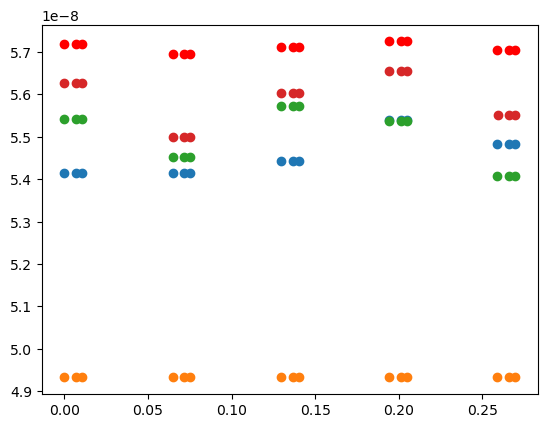

In [16]:
alpha_visit_5 = np.load('/Users/soumit/Downloads/alpha_cen_stuff/cute/alpha_cen_visit5_2025_fluxes.npz' , allow_pickle= True)

print(alpha_visit_5)

phot1_vis5 = alpha_visit_5['phot1_vis5']
phot2_vis5 = alpha_visit_5['phot2_vis5']
chrom_vis5 = alpha_visit_5['chrom_vis5']
dates_vis5 = alpha_visit_5['dates_vis5']

print(dates_vis5)


# assume your array is called "dt_array"
dt_vis_5 = np.array(dates_vis5)   # ensure numpy array of datetime objects

# convert to float days relative to first timestamp
t_days_5 = np.array([(dt - dt_vis_5[0]).total_seconds() / 86400.0 for dt in dt_vis_5])

print(t_days_5)


plt.scatter(t_days_5 , phot1_vis5)
plt.scatter(t_days_4 , phot1_vis4)
plt.scatter(t_days_3 , phot1_vis3 , color ='red')
plt.scatter(t_days_2 , phot1_vis2)
plt.scatter(t_days_1 , phot1_vis1)

avg_phot1_vis5 = np.average(phot1_vis5)



In [17]:
import numpy as np

def process_visit(npz_path, visit_number):
    data = np.load(npz_path, allow_pickle=True)

    phot1 = data[f'phot1_vis{visit_number}']
    phot2 = data[f'phot2_vis{visit_number}']
    chrom = data[f'chrom_vis{visit_number}']
    dates = data[f'dates_vis{visit_number}']

    # Convert to float days
    dt = np.array(dates)
    t_days = np.array([(d - dt[0]).total_seconds() / 86400.0 for d in dt])

    # Integrate with NumPy trapezoidal rule
    total_flux_phot1 = np.trapezoid(phot1, t_days)

    return {
        "t_days": t_days,
        "phot1": phot1,
        "phot2": phot2,
        "chrom": chrom,
        "total_flux_phot1": total_flux_phot1,
    }


In [18]:
visit_fluxes = {}

for v in range(1, 11):
    path = f"/Users/soumit/Downloads/alpha_cen_stuff/cute/alpha_cen_visit{v}_2025_fluxes.npz"
    visit_fluxes[v] = process_visit(path, v)


In [19]:
ref_flux = visit_fluxes[3]["total_flux_phot1"]

percent_diff = {}
for v in visit_fluxes:
    Fx = visit_fluxes[v]["total_flux_phot1"]
    percent_diff[v] = 100 * (Fx - ref_flux) / ref_flux


In [20]:
for v in sorted(percent_diff):
    print(f"Visit {v}: {percent_diff[v]:.2f}% difference from Visit 3")


Visit 1: -2.14% difference from Visit 3
Visit 2: -3.54% difference from Visit 3
Visit 3: 0.00% difference from Visit 3
Visit 4: -13.65% difference from Visit 3
Visit 5: -4.41% difference from Visit 3
Visit 6: -16.63% difference from Visit 3
Visit 7: -22.08% difference from Visit 3
Visit 8: -24.95% difference from Visit 3
Visit 9: -13.04% difference from Visit 3
Visit 10: -24.43% difference from Visit 3


In [21]:
correction_factors = {}
for v in visit_fluxes:
    Fx = visit_fluxes[v]["total_flux_phot1"]
    correction_factors[v] = ref_flux / Fx

for v in sorted(correction_factors):
    print(f"Correction factor for Visit {v}: {correction_factors[v]:.4f}")


Correction factor for Visit 1: 1.0219
Correction factor for Visit 2: 1.0367
Correction factor for Visit 3: 1.0000
Correction factor for Visit 4: 1.1581
Correction factor for Visit 5: 1.0461
Correction factor for Visit 6: 1.1995
Correction factor for Visit 7: 1.2834
Correction factor for Visit 8: 1.3325
Correction factor for Visit 9: 1.1499
Correction factor for Visit 10: 1.3233



--- Percentage Increase Needed to Match Visit 3 ---
Visit 1: increase by 2.19%
Visit 2: increase by 3.67%
Visit 3: increase by 0.00%
Visit 4: increase by 15.81%
Visit 5: increase by 4.61%
Visit 6: increase by 19.95%
Visit 7: increase by 28.34%
Visit 8: increase by 33.25%
Visit 9: increase by 14.99%
Visit 10: increase by 32.33%


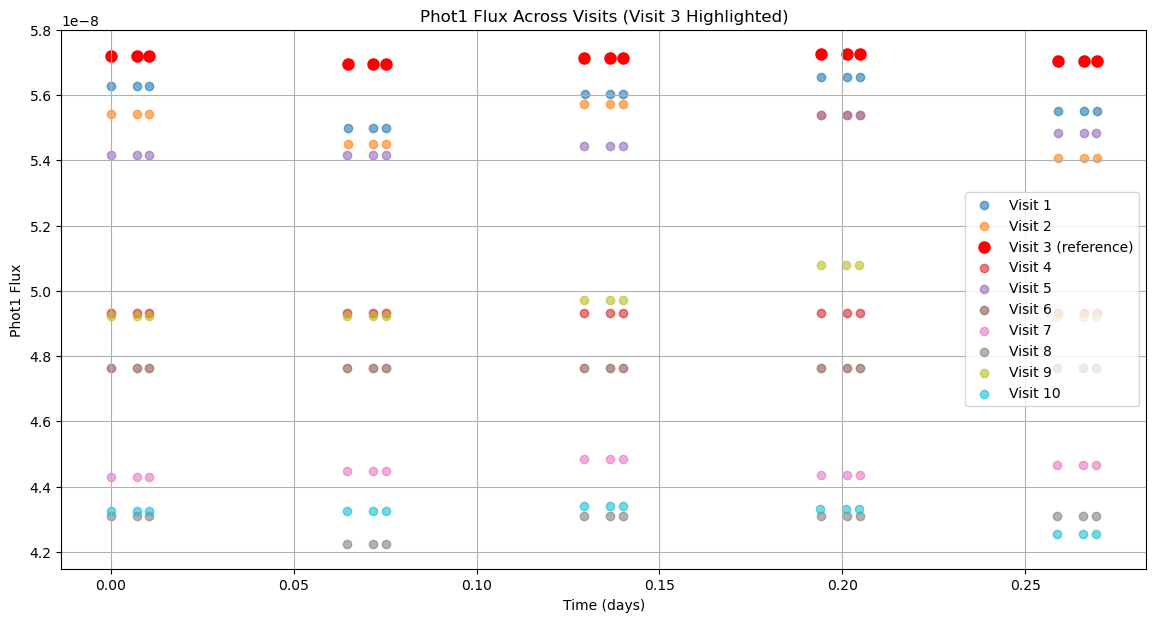

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------
# Function to process any visit
# ---------------------
def process_visit(npz_path, visit_number):
    data = np.load(npz_path, allow_pickle=True)

    phot1 = data[f'phot1_vis{visit_number}']
    phot2 = data[f'phot2_vis{visit_number}']
    chrom = data[f'chrom_vis{visit_number}']
    dates = data[f'dates_vis{visit_number}']

    # Convert to datetime array
    dt = np.array(dates)

    # Convert to float days relative to first timestamp
    t_days = np.array([(d - dt[0]).total_seconds() / 86400.0 for d in dt])

    # Integrated flux using NumPy trapezoidal rule
    total_flux = np.trapezoid(phot1, t_days)

    return t_days, phot1, phot2, chrom, total_flux


# ---------------------
# Load all visits 1–10
# ---------------------
visit_data = {}
for v in range(1, 11):
    path = f"/Users/soumit/Downloads/alpha_cen_stuff/cute/alpha_cen_visit{v}_2025_fluxes.npz"
    t_days, phot1, phot2, chrom, total_flux = process_visit(path, v)
    visit_data[v] = {"t": t_days, "phot1": phot1, "phot2": phot2,
                     "chrom": chrom, "flux": total_flux}

# ---------------------
# Compute % differences relative to visit 3
# ---------------------
ref_flux = visit_data[3]["flux"]

increase_needed = {}

for v in visit_data:
    Fx = visit_data[v]["flux"]
    increase_needed[v] = 100 * (ref_flux / Fx - 1)

print("\n--- Percentage Increase Needed to Match Visit 3 ---")
for v in sorted(increase_needed):
    print(f"Visit {v}: increase by {increase_needed[v]:.2f}%")

# ---------------------
# Plot all phot1 curves, highlight Visit 3
# ---------------------
plt.figure(figsize=(14, 7))

colors = plt.cm.tab10(np.linspace(0, 1, 10))  # 10 distinct colors

for idx, v in enumerate(range(1, 11)):
    t = visit_data[v]["t"]
    phot1 = visit_data[v]["phot1"]

    if v == 3:
        plt.scatter(t, phot1, color='red', linewidth=3, label="Visit 3 (reference)")
    else:
        plt.scatter(t, phot1, color=colors[idx], alpha=0.6, label=f"Visit {v}")

plt.xlabel("Time (days)")
plt.ylabel("Phot1 Flux")
plt.title("Phot1 Flux Across Visits (Visit 3 Highlighted)")
plt.legend()
plt.grid(True)
plt.show()



In [23]:
avg_percent = {}

for v in visit_data:
    avg_percent[v] = 0.5 * (increase_p1[v] + increase_p2[v])

print("\n--- Average % Change from Phot1 and Phot2 ---")
for v in sorted(avg_percent):
    print(f"Visit {v}: {avg_percent[v]:.2f}%")



for v in visit_data:
    if v == 3:
        # Reference visit — no change
        visit_data[v]["chrom_corrected"] = visit_data[v]["chrom"]
    else:
        scale = 1 + avg_percent[v] / 100.0
        visit_data[v]["chrom_corrected"] = visit_data[v]["chrom"] * scale



print("\n--- Chromosphere Scaling Applied ---")
for v in sorted(avg_percent):
    if v == 3:
        print(f"Visit {v}: unchanged (reference)")
    else:
        print(f"Visit {v}: chromosphere increased by {avg_percent[v]:.2f}%")


NameError: name 'increase_p1' is not defined

### Getting Time

### Refer from here

In [24]:

#----------------------------
def calculate_time_difference(start_time, end_time):
    """Calculates the time difference between two datetime objects."""

    time_difference = end_time - start_time

    days = time_difference.days
    hours, remainder = divmod(time_difference.seconds, 3600)
    minutes, seconds = divmod(remainder, 60)

    return days, hours, minutes, seconds
#--------------------------------
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth

from astropy.time import Time



#---------------------------MAIN PROGRAM-------------------
# Restore the CUTE Alpha Centauri spectra from the .sav files

fname_prof = '/Users/soumit/Downloads/Astronomy/Alpha_Cen/2025/CUTE2025_visit12345678910_reduced_v1.sav'
fname_sou  = '/Users/soumit/Downloads/Astronomy/Alpha_Cen/version_2025.sav'

# Load both files with readsav
sav_data_prof = readsav(fname_prof)
sav_data      = loadmat(fname_sou)

# wavelength solution from professor’s file
cute_wavesol = sav_data_prof['wave_sol']
mxw = cute_wavesol.max()
mnw = cute_wavesol.min()

# Your fluxes (from your sav file)
cute_ff1 = np.array(sav_data['flux_units_star1'])
cute_ff2 = np.array(sav_data['flux_units_star2'])
cute_ff3 = np.array(sav_data['flux_units_star3'])
cute_ff4 = np.array(sav_data['flux_units_star4'])
cute_ff5 = np.array(sav_data['flux_units_star5'])
cute_ff6 = np.array(sav_data['flux_units_star6'])
cute_ff7 = np.array(sav_data['flux_units_star7'])
cute_ff8 = np.array(sav_data['flux_units_star8'])
cute_ff9 = np.array(sav_data['flux_units_star9'])
cute_ff10 = np.array(sav_data['flux_units_star10'])

# Backgrounds and raw spectra (renaming your sigdn/sigup usage)
cute_ff1_sigup = sav_data['spectrum1'] 
cute_ff1_sigdn = sav_data['background1']
cute_ff2_sigup = sav_data['spectrum2'] 
cute_ff2_sigdn = sav_data['background2']
cute_ff3_sigup = sav_data['spectrum3'] 
cute_ff3_sigdn = sav_data['background3']
cute_ff4_sigup = sav_data['spectrum4'] 
cute_ff4_sigdn = sav_data['background4']
cute_ff5_sigup = sav_data['spectrum5'] 
cute_ff5_sigdn = sav_data['background5']
cute_ff6_sigup = sav_data['spectrum6'] 
cute_ff6_sigdn = sav_data['background6']
cute_ff7_sigup = sav_data['spectrum7'] 
cute_ff7_sigdn = sav_data['background7']
cute_ff8_sigup = sav_data['spectrum8'] 
cute_ff8_sigdn = sav_data['background8']
cute_ff9_sigup = sav_data['spectrum9'] 
cute_ff9_sigdn = sav_data['background9']
cute_ff10_sigup = sav_data['spectrum10'] 
cute_ff10_sigdn = sav_data['background10']

# Number of exposures in each visit

nfiles1 = np.shape(cute_ff1)[1]
nfiles2 = np.shape(cute_ff2)[1]
nfiles3 = np.shape(cute_ff3)[1]
nfiles4 = np.shape(cute_ff4)[1]
nfiles5 = np.shape(cute_ff5)[1]
nfiles6 = np.shape(cute_ff6)[1]
nfiles7 = np.shape(cute_ff7)[1]
nfiles8 = np.shape(cute_ff8)[1]
nfiles9 = np.shape(cute_ff9)[1]
nfiles10 = np.shape(cute_ff10)[1]

nfiles4        = np.shape(cute_ff4)[1]
nfiles5        = np.shape(cute_ff5)[1]
nfiles6        = np.shape(cute_ff6)[1]
nfiles7        = np.shape(cute_ff7)[1]

nfiles8        = np.shape(cute_ff8)[1]
dt_arr1        = sav_data_prof['date_obs1']
dt_arr2       = sav_data_prof['date_obs2']
dt_arr3       = sav_data_prof['date_obs3']
dt_arr4        = sav_data_prof['date_obs4']
dt_arr5        = sav_data_prof['date_obs5']
dt_arr6        = sav_data_prof['date_obs6']
dt_arr7        = sav_data_prof['date_obs7']
dt_arr8        = sav_data_prof['date_obs8']
dt_arr9        = sav_data_prof['date_obs9']
dt_arr10        = sav_data_prof['date_obs10']

timearr1       = np.zeros(shape=nfiles1,dtype=float)
timearr2       = np.zeros(shape=nfiles2,dtype=float)
timearr3       = np.zeros(shape=nfiles3,dtype=float)
timearr4       = np.zeros(shape=nfiles4,dtype=float)
timearr5       = np.zeros(shape=nfiles5,dtype=float)
timearr6       = np.zeros(shape=nfiles6,dtype=float)
timearr7       = np.zeros(shape=nfiles7,dtype=float)
timearr8       = np.zeros(shape=nfiles8,dtype=float)
timearr9       = np.zeros(shape=nfiles9,dtype=float)
timearr10       = np.zeros(shape=nfiles10,dtype=float)

orbit_time1    = []
orbit_time2    = []
orbit_time3    = []
orbit_time4    = []
orbit_time5    = []
orbit_time6    = []
orbit_time7    = []
orbit_time8    = []
orbit_time9    = []
orbit_time10   = []
dates1         = []
dates2         = []
dates3         = []
dates4         = []
dates5         = []
dates6         = []
dates7         = []
dates8         = []
dates9         = []
dates10        = []

dt1str         = []
dt2str         = []
dt3str         = []
dt4str         = []
dt5str         = []
dt6str         = []
dt7str         = []
dt8str         = []
dt9str         = []
dt10str        = []

# Time arrays (from professor’s sav, since your file doesn’t have dates)
# dt_arr4 = sav_data_prof['date_obs4']
# dt_arr5 = sav_data_prof['date_obs5']
# dt_arr6 = sav_data_prof['date_obs6']
# dt_arr7 = sav_data_prof['date_obs7']
# dt_arr8 = sav_data_prof['date_obs8']

# timearr4 = np.zeros(shape=nfiles4, dtype=float)
# timearr5 = np.zeros(shape=nfiles5, dtype=float)
# timearr6 = np.zeros(shape=nfiles6, dtype=float)
# timearr7 = np.zeros(shape=nfiles7, dtype=float)
# timearr8 = np.zeros(shape=nfiles8, dtype=float)

# orbit_time4, orbit_time5, orbit_time6, orbit_time7, orbit_time8 = [], [], [], [], []
# dates4, dates5, dates6, dates7, dates8 = [], [], [], [], []
# dt4str, dt5str, dt6str, dt7str, dt8str = [], [], [], [], []


def to_mjd(dt_array):
    """Convert byte-string datetime array from .sav into float MJD."""
    # decode bytes to regular strings
    decoded = [d.decode('utf-8') if isinstance(d, (bytes, bytearray)) else d for d in dt_array]
    # convert to MJD
    t = Time(decoded, format='isot', scale='utc')
    return t.mjd

# Convert all visits
t1 = to_mjd(dt_arr1)
t2 = to_mjd(dt_arr2)
t3 = to_mjd(dt_arr3)
t4 = to_mjd(dt_arr4)
t5 = to_mjd(dt_arr5)
t6 = to_mjd(dt_arr6)
t7 = to_mjd(dt_arr7)
t8 = to_mjd(dt_arr8)
t9 = to_mjd(dt_arr9)
t10 = to_mjd(dt_arr10)


In [25]:
import numpy as np

time_all = np.concatenate([t1, t2, t3, t4, t5, t6, t7, t8, t9, t10])

print("Combined array length:", len(time_all))
print("Is sorted:", np.all(np.diff(time_all) > 0))
print("Total time span:", np.min(time_all), "→", np.max(time_all),
      f"({np.max(time_all) - np.min(time_all):.1f} days)")

if not np.all(np.diff(time_all) > 0):
    disorder = np.where(np.diff(time_all) < 0)[0]
    print("⚠️ Disorder detected at indices:", disorder[:5])
    print("Values around first disorder:")
    print(time_all[disorder[0]-2:disorder[0]+3])






Combined array length: 199
Is sorted: True
Total time span: 60792.24086805555 → 60855.5327662037 (63.3 days)


In [26]:
print("\n--- Chromosphere Change Per Visit ---")

for v in sorted(visit_data.keys()):
    original = visit_data[v]["chrom"]
    corrected = visit_data[v]["chrom_corrected"]

    if v == 3:
        print(f"Visit {v}: Reference — no change")
    else:
        percent = avg_percent[v]

        # compute total change per visit (individual points)
        diff_array = corrected - original
        avg_change = np.mean(diff_array)

        print(f"Visit {v}: increased by {percent:.2f}%  |  "
              f"mean flux change = {avg_change:.4e}")



--- Chromosphere Change Per Visit ---


KeyError: 'chrom_corrected'

In [27]:
total_points = len(chrom_corrected_all)
print("Total number of chromosphere data points =", total_points)


NameError: name 'chrom_corrected_all' is not defined

In [28]:
# Combine all corrected chrom values into one array
chrom_corrected_all = np.concatenate(
    [visit_data[v]["chrom_corrected"] for v in sorted(visit_data.keys())]
)

# Print total number of points
total_points = len(chrom_corrected_all)
print("Total number of chromosphere data points =", total_points)


KeyError: 'chrom_corrected'


--- Average % Increase per Visit (Phot1 + Phot2) ---
Visit 1: 2.18%
Visit 2: 3.76%
Visit 3: 0.00%
Visit 4: 16.99%
Visit 5: 7.25%
Visit 6: 20.37%
Visit 7: 25.47%
Visit 8: 25.59%
Visit 9: 11.38%
Visit 10: 27.39%

--- Chromosphere Scaling Applied ---
Visit 1: increased by 2.18%
Visit 2: increased by 3.76%
Visit 3: unchanged (reference)
Visit 4: increased by 16.99%
Visit 5: increased by 7.25%
Visit 6: increased by 20.37%
Visit 7: increased by 25.47%
Visit 8: increased by 25.59%
Visit 9: increased by 11.38%
Visit 10: increased by 27.39%

Total time samples = 150
Total chromosphere samples = 150


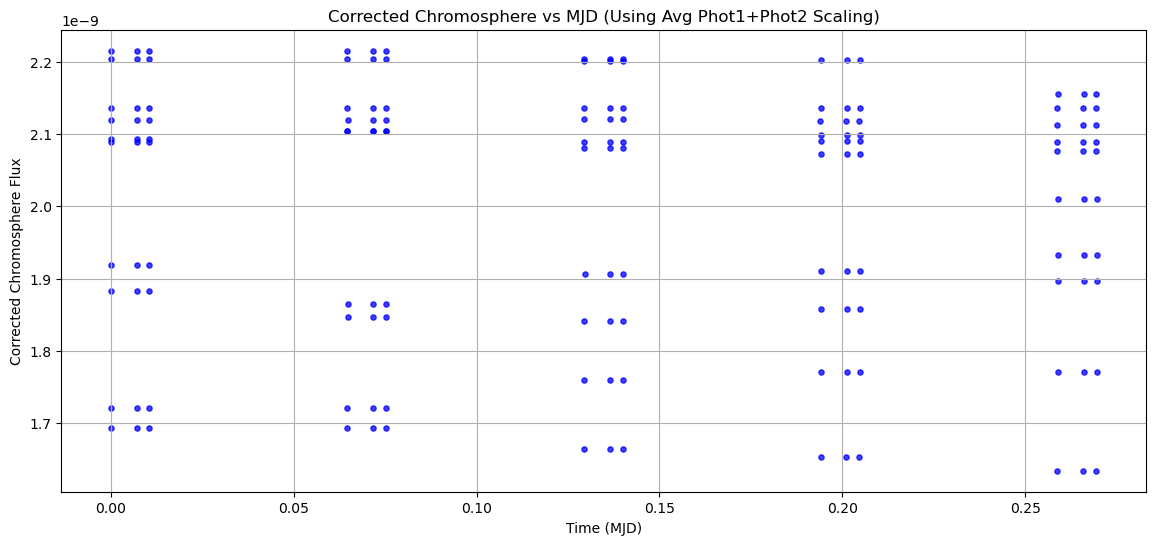

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Compute % change of phot1 and phot2 relative to Visit 3
# ---------------------------------------------------------

# Phot1 percent change
increase_p1 = {}
for v in visit_data:
    ref_flux_p1 = visit_data[3]["phot1"].sum()
    this_flux_p1 = visit_data[v]["phot1"].sum()
    increase_p1[v] = 100 * (ref_flux_p1 / this_flux_p1 - 1)

# Phot2 percent change
increase_p2 = {}
for v in visit_data:
    ref_flux_p2 = visit_data[3]["phot2"].sum()
    this_flux_p2 = visit_data[v]["phot2"].sum()
    increase_p2[v] = 100 * (ref_flux_p2 / this_flux_p2 - 1)

# ---------------------------------------------------------
# 2. Compute average percent change per visit
# ---------------------------------------------------------
avg_percent = {}
for v in visit_data:
    avg_percent[v] = 0.5 * (increase_p1[v] + increase_p2[v])

print("\n--- Average % Increase per Visit (Phot1 + Phot2) ---")
for v in sorted(avg_percent.keys()):
    print(f"Visit {v}: {avg_percent[v]:.2f}%")


# ---------------------------------------------------------
# 3. Apply average % increase to chromosphere for each visit
# ---------------------------------------------------------
for v in visit_data:
    if v == 3:
        # Visit 3 is the reference (unchanged)
        visit_data[v]["chrom_corrected"] = visit_data[v]["chrom"]
    else:
        scale = 1 + avg_percent[v] / 100.0
        visit_data[v]["chrom_corrected"] = visit_data[v]["chrom"] * scale

print("\n--- Chromosphere Scaling Applied ---")
for v in sorted(avg_percent.keys()):
    if v == 3:
        print(f"Visit {v}: unchanged (reference)")
    else:
        print(f"Visit {v}: increased by {avg_percent[v]:.2f}%")


# ---------------------------------------------------------
# 4. Build the global arrays (MJD + corrected chromosphere)
# ---------------------------------------------------------
time_all = np.concatenate([visit_data[v]["t"] for v in range(1, 11)])
chrom_corrected_all = np.concatenate([visit_data[v]["chrom_corrected"] for v in range(1, 11)])

print("\nTotal time samples =", len(time_all))
print("Total chromosphere samples =", len(chrom_corrected_all))


# ---------------------------------------------------------
# 5. Plot corrected chromosphere vs MJD
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.scatter(time_all, chrom_corrected_all, s=14, color='blue', alpha=0.75)

plt.xlabel("Time (MJD)")
plt.ylabel("Corrected Chromosphere Flux")
plt.title("Corrected Chromosphere vs MJD (Using Avg Phot1+Phot2 Scaling)")
plt.grid(True)
plt.show()



 Best-fit rotation period = 1.000 days


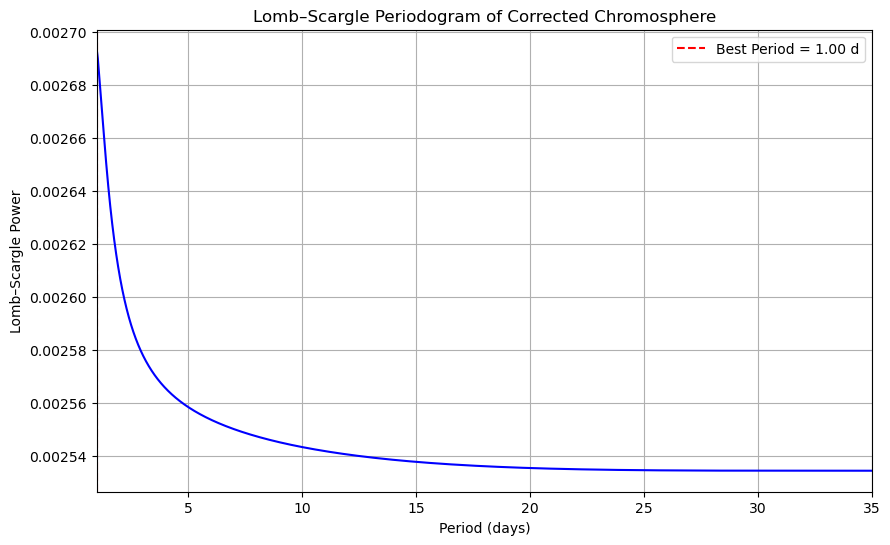

In [30]:
from astropy.timeseries import LombScargle
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Lomb–Scargle on corrected chromosphere
# ---------------------------------------------------------

# Your data (already constructed earlier)
t = time_all                      # MJD time array (199 pts)
y = chrom_corrected_all           # corrected chromosphere

# Define period search range
min_period = 1      # days
max_period = 35      # days

# Convert to frequency range
min_freq = 1 / max_period
max_freq = 1 / min_period

# Compute LS periodogram
frequency, power = LombScargle(t, y).autopower( minimum_frequency=min_freq,  maximum_frequency=max_freq, samples_per_peak=5000)

# Convert to periods
period = 1 / frequency

# Find best period (peak)
best_period = period[np.argmax(power)]
print(f"\n Best-fit rotation period = {best_period:.3f} days")

# ---------------------------------------------------------
# Plot LS Periodogram
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(period, power, color='blue')
plt.axvline(best_period, color='red', linestyle='--',
            label=f"Best Period = {best_period:.2f} d")

plt.xlim(min_period, max_period)
plt.xlabel("Period (days)")
plt.ylabel("Lomb–Scargle Power")
plt.title("Lomb–Scargle Periodogram of Corrected Chromosphere")
plt.grid(True)
plt.legend()
plt.show()


## Time for 2024 dataset

In [44]:
from scipy.io import readsav
import numpy as np
from astropy.time import Time

cute_time = readsav('/Users/soumit/Downloads/Astronomy/Alpha_Cen/CUTE_visit45678_reduced_v3.sav')

date_4 = cute_time['date_obs4']
date_5 = cute_time['date_obs5']
date_6 = cute_time['date_obs6']
date_7 = cute_time['date_obs7']
date_8 = cute_time['date_obs8']



In [45]:
for v in range(4, 8):
    path = f"/Users/soumit/Downloads/Astronomy/Alpha_Cen/CUTE_2024/alpha_cen_visit{v}_2024_fluxes.npz"
    

In [46]:
path_4 = np.load('/Users/soumit/Downloads/Astronomy/Alpha_Cen/CUTE_2024/alpha_cen_visit4_2024_fluxes.npz' ,allow_pickle = True)
path_5 = np.load('/Users/soumit/Downloads/Astronomy/Alpha_Cen/CUTE_2024/alpha_cen_visit5_2024_fluxes.npz' ,allow_pickle = True)
path_6 = np.load('/Users/soumit/Downloads/Astronomy/Alpha_Cen/CUTE_2024/alpha_cen_visit6_2024_fluxes.npz' ,allow_pickle = True)
path_7 = np.load('/Users/soumit/Downloads/Astronomy/Alpha_Cen/CUTE_2024/alpha_cen_visit7_2024_fluxes.npz' ,allow_pickle = True)
path_8 = np.load('/Users/soumit/Downloads/Astronomy/Alpha_Cen/CUTE_2024/alpha_cen_visit8_2024_fluxes.npz' ,allow_pickle = True)

print(path_4, path_5,path_6,path_7,path_8)


NpzFile '/Users/soumit/Downloads/Astronomy/Alpha_Cen/CUTE_2024/alpha_cen_visit4_2024_fluxes.npz' with keys: phot1_vis4_24, phot2_vis4_24, chrom_vis4_24, dates_vis4_24 NpzFile '/Users/soumit/Downloads/Astronomy/Alpha_Cen/CUTE_2024/alpha_cen_visit5_2024_fluxes.npz' with keys: phot1_vis5_24, phot2_vis5_24, chrom_vis5_24, dates_vis5_24 NpzFile '/Users/soumit/Downloads/Astronomy/Alpha_Cen/CUTE_2024/alpha_cen_visit6_2024_fluxes.npz' with keys: phot1_vis6_24, phot2_vis6_24, chrom_vis6_24, dates_vis6_24 NpzFile '/Users/soumit/Downloads/Astronomy/Alpha_Cen/CUTE_2024/alpha_cen_visit7_2024_fluxes.npz' with keys: phot1_vis7_24, phot2_vis7_24, chrom_vis7_24, dates_vis7_24 NpzFile '/Users/soumit/Downloads/Astronomy/Alpha_Cen/CUTE_2024/alpha_cen_visit8_2024_fluxes.npz' with keys: phot1_vis8_24, phot2_vis8_24, chrom_vis8_24, dates_vis8_24


In [34]:
# print(path.files)

In [35]:
dates4 = path_4['dates_vis4_24']
date5 = path_5['dates_vis5_24']
date6 = path_6['dates_vis6_24']
date7 = path_7['dates_vis7_24']
date8 = path_8['dates_vis8_24']

print(dates4, dates5, dates6, dates7, dates8)

[datetime.datetime(2024, 4, 27, 9, 10, 6)
 datetime.datetime(2024, 4, 27, 9, 15, 11)
 datetime.datetime(2024, 4, 27, 9, 20, 16)
 datetime.datetime(2024, 4, 27, 9, 25, 21)
 datetime.datetime(2024, 4, 27, 10, 45, 6)
 datetime.datetime(2024, 4, 27, 10, 50, 11)
 datetime.datetime(2024, 4, 27, 10, 55, 16)
 datetime.datetime(2024, 4, 27, 18, 50, 1)
 datetime.datetime(2024, 4, 27, 18, 55, 6)] [] [] [] []


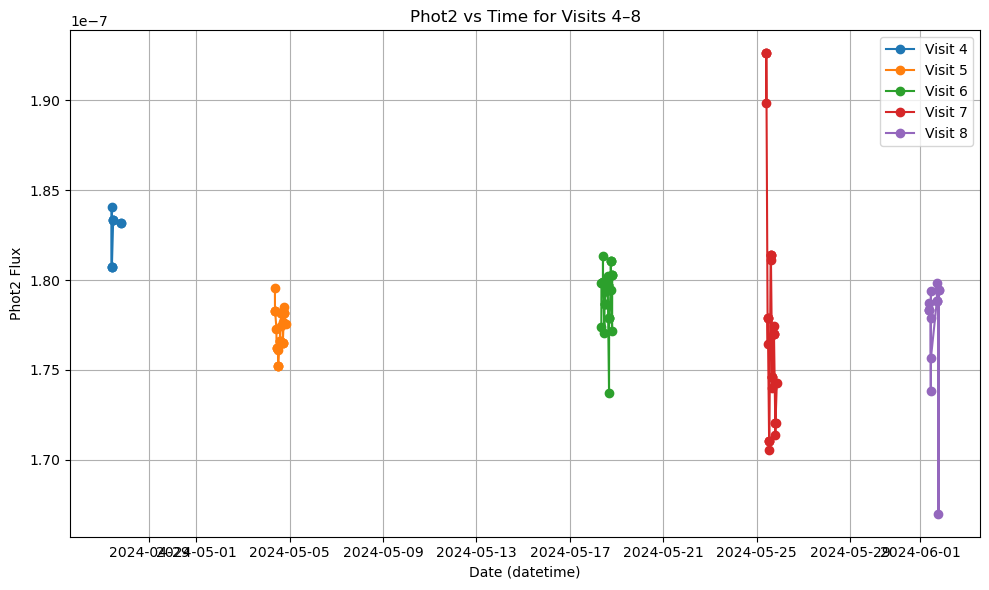

In [36]:
import matplotlib.pyplot as plt

# Extract phot2 and dates for each visit
dates4 = path_4['dates_vis4_24']
phot2_4 = path_4['phot2_vis4_24']

dates5 = path_5['dates_vis5_24']
phot2_5 = path_5['phot2_vis5_24']

dates6 = path_6['dates_vis6_24']
phot2_6 = path_6['phot2_vis6_24']

dates7 = path_7['dates_vis7_24']
phot2_7 = path_7['phot2_vis7_24']

dates8 = path_8['dates_vis8_24']
phot2_8 = path_8['phot2_vis8_24']

# --- Plot ---
plt.figure(figsize=(10,6))

plt.plot(dates4, phot2_4, 'o-', label="Visit 4")
plt.plot(dates5, phot2_5, 'o-', label="Visit 5")
plt.plot(dates6, phot2_6, 'o-', label="Visit 6")
plt.plot(dates7, phot2_7, 'o-', label="Visit 7")
plt.plot(dates8, phot2_8, 'o-', label="Visit 8")

plt.xlabel("Date (datetime)")
plt.ylabel("Phot2 Flux")
plt.title("Phot2 vs Time for Visits 4–8")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Best Period (days): 0.9646344232515894


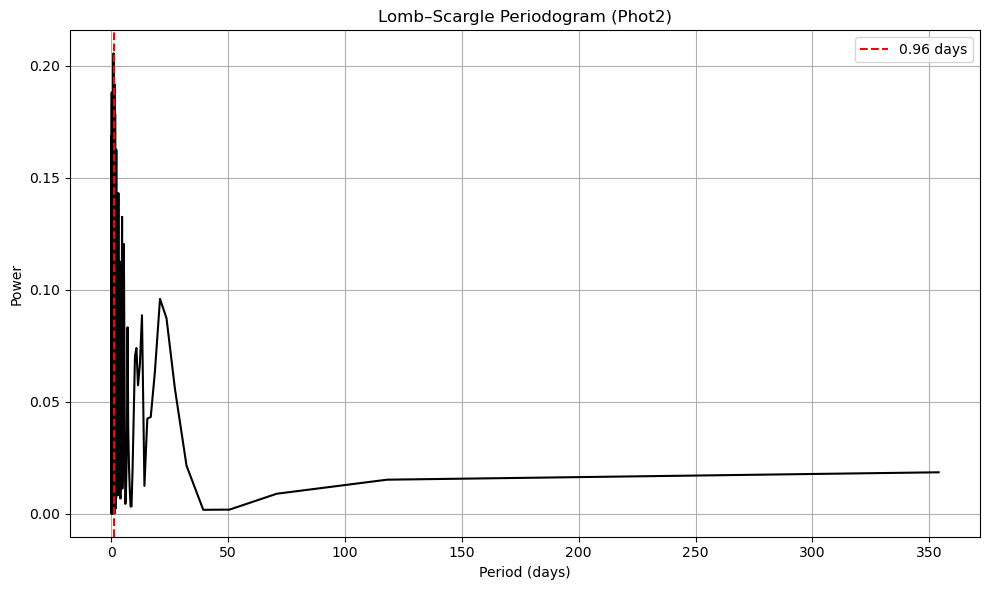

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

# -----------------------------
# 1. Gather all dates & phot2
# -----------------------------
dates_all = np.concatenate([dates4, dates5, dates6, dates7, dates8])
phot2_all = np.concatenate([phot2_4, phot2_5, phot2_6, phot2_7, phot2_8])

# -----------------------------
# 2. Convert datetime → days
# -----------------------------
t0 = dates_all[0]  # reference starting date

# convert to number of days
t_days = np.array([(d - t0).total_seconds() / 86400 for d in dates_all], dtype=float)

y = phot2_all.astype(float)

# -----------------------------
# 3. Lomb–Scargle periodogram
# -----------------------------
frequency, power = LombScargle(t_days, y).autopower()

best_freq = frequency[np.argmax(power)]
best_period = 1 / best_freq

print("Best Period (days):", best_period)

# -----------------------------
# 4. Plot LS: power vs period
# -----------------------------
period = 1 / frequency

plt.figure(figsize=(10,6))
plt.plot(period, power, 'k-')
plt.axvline(best_period, color='red', linestyle='--', label=f"{best_period:.2f} days")

plt.xlabel("Period (days)")
plt.ylabel("Power")
plt.title("Lomb–Scargle Periodogram (Phot2)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


Best period (days): 20.726709438196764


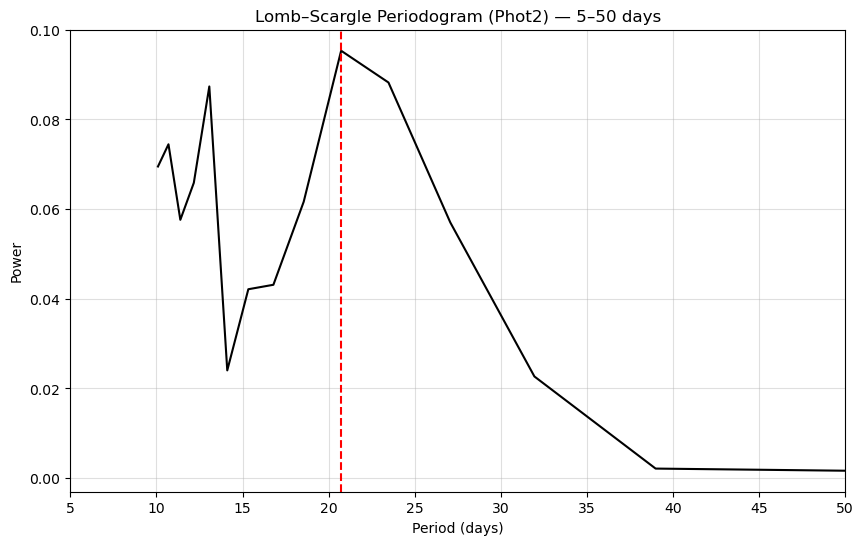

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

# -----------------------------------------
# Combine dates + phot2
# -----------------------------------------
dates_all = np.concatenate([dates4, dates5, dates6, dates7, dates8])
phot2_all = np.concatenate([phot2_4, phot2_5, phot2_6, phot2_7, phot2_8])

# -----------------------------------------
# Convert datetime → days
# -----------------------------------------
t0 = dates_all[0]
t_days = np.array([(d - t0).total_seconds() / 86400 for d in dates_all], float)
y = phot2_all.astype(float)

# -----------------------------------------
# Lomb–Scargle: set period limits 5–50 days
# -----------------------------------------
min_period = 10    # days
max_period = 50    # days

min_freq = 1 / max_period
max_freq = 1 / min_period

frequency, power = LombScargle(t_days, y).autopower(
    minimum_frequency=min_freq,
    maximum_frequency=max_freq

)

# best peak
best_freq = frequency[np.argmax(power)]
best_period = 1 / best_freq
print("Best period (days):", best_period)

# -----------------------------------------
# Plot Periodogram
# -----------------------------------------
period = 1 / frequency

plt.figure(figsize=(10,6))
plt.plot(period, power, 'k-')
plt.axvline(best_period, color='red', linestyle='--')
plt.xlabel("Period (days)")
plt.ylabel("Power")
plt.title("Lomb–Scargle Periodogram (Phot2) — 5–50 days")
plt.xlim(5,50)
plt.grid(alpha=0.4)
plt.show()


NpzFile '/Users/soumit/Downloads/alpha_cen_CUTE2025_mgii_calc.npz' with keys: date_obs, mgii_ind, mgii_err
['2025-04-27 05:46' '2025-04-27 05:51' '2025-04-27 05:57'
 '2025-04-27 06:02' '2025-04-27 07:20' '2025-04-27 07:25'
 '2025-04-27 07:30' '2025-04-27 07:35' '2025-04-27 08:53'
 '2025-04-27 08:58' '2025-04-27 09:03' '2025-04-27 09:08'
 '2025-04-27 10:26' '2025-04-27 10:31' '2025-04-27 10:36'
 '2025-04-27 10:41' '2025-04-27 11:59' '2025-04-27 12:04'
 '2025-04-27 12:10' '2025-04-27 12:15' '2025-05-04 05:36'
 '2025-05-04 05:41' '2025-05-04 05:46' '2025-05-04 05:51'
 '2025-05-04 07:09' '2025-05-04 07:14' '2025-05-04 07:19'
 '2025-05-04 07:25' '2025-05-04 08:42' '2025-05-04 08:48'
 '2025-05-04 08:53' '2025-05-04 08:58' '2025-05-04 10:16'
 '2025-05-04 10:21' '2025-05-04 10:26' '2025-05-04 10:31'
 '2025-05-04 11:49' '2025-05-04 11:54' '2025-05-04 11:59'
 '2025-05-04 12:04' '2025-05-11 06:57' '2025-05-11 07:02'
 '2025-05-11 07:08' '2025-05-11 07:13' '2025-05-11 08:31'
 '2025-05-11 08:36' '20

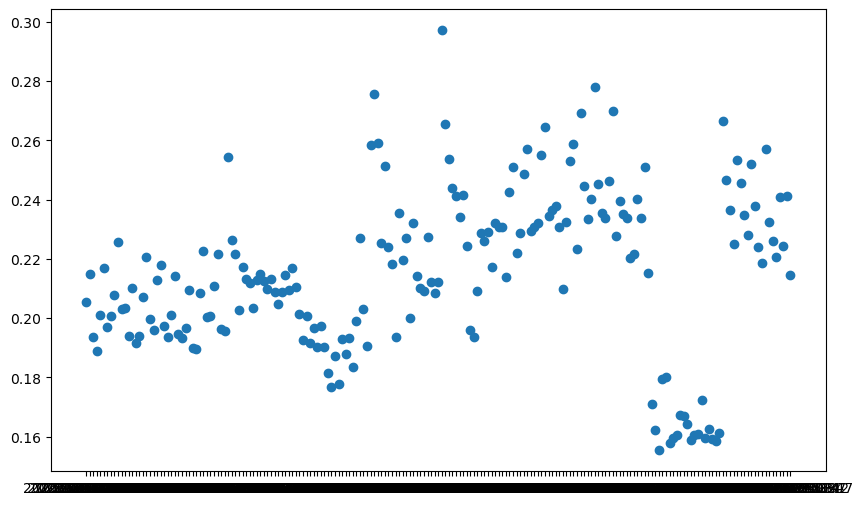

In [39]:
alpha_path_name = np.load('/Users/soumit/Downloads/alpha_cen_CUTE2025_mgii_calc.npz' , allow_pickle=True)


print(alpha_path_name)

date_obs = alpha_path_name['date_obs']
mgii_ind = alpha_path_name['mgii_ind']
mgii_err = alpha_path_name['mgii_err']


plt.figure(figsize=(10,6))
plt.scatter(date_obs , mgii_ind)



print(date_obs)

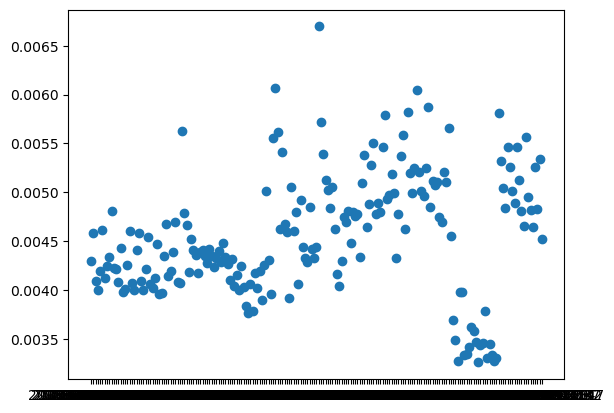

In [40]:

plt.scatter(date_obs , mgii_err)


In [41]:
# Converting time to mjd 
t_mjd = Time(date_obs, format='iso').mjd
t_days = t_mjd - t_mjd[0]
y = np.array(mgii_ind, float)


Best period (days): 3.5335369844132085


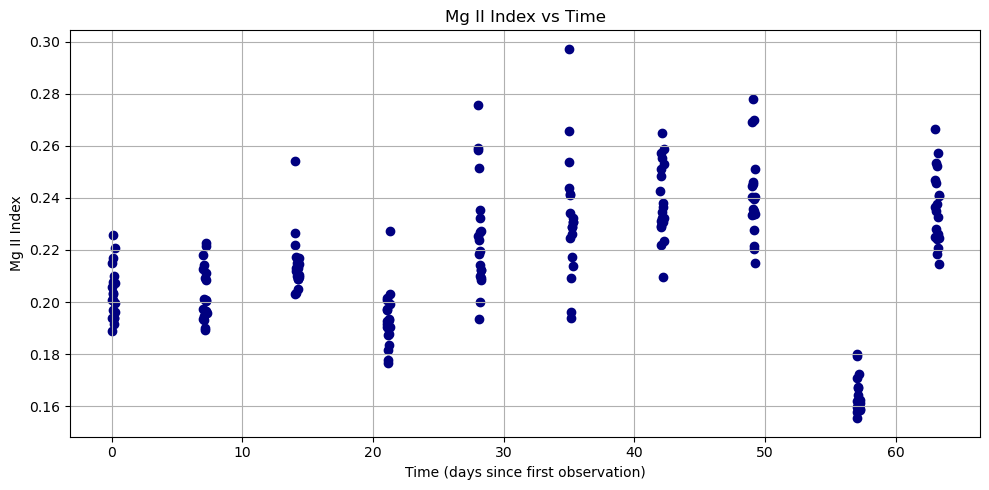

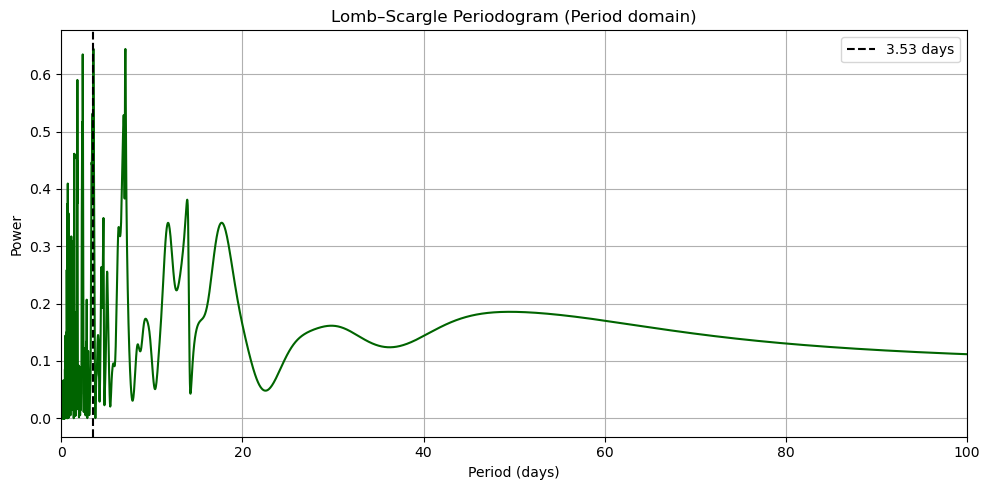

In [42]:
frequency, power = LombScargle(t_days, y).autopower(samples_per_peak=5000)

best_freq = frequency[np.argmax(power)]
best_period = 1 / best_freq   # already in DAYS

print("Best period (days):", best_period)

# -------------------------------------------------------
# 3. Plot Mg II vs Time
# -------------------------------------------------------
plt.figure(figsize=(10,5))
plt.scatter(t_days, y, color='navy')
plt.xlabel("Time (days since first observation)")
plt.ylabel("Mg II Index")
plt.title("Mg II Index vs Time")
plt.grid(True)
plt.tight_layout()
plt.show()



# -------------------------------------------------------
# 5. Plot LS: Power vs Period
# -------------------------------------------------------
period = 1 / frequency

plt.figure(figsize=(10,5))
plt.plot(period, power, 'darkgreen')
plt.axvline(best_period, color='black', linestyle='--', label=f"{best_period:.2f} days")
plt.xlabel("Period (days)")
plt.xlim(0, 100)   # You can expand
plt.ylabel("Power")
plt.title("Lomb–Scargle Periodogram (Period domain)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Best period (days): 3.5365380830606172


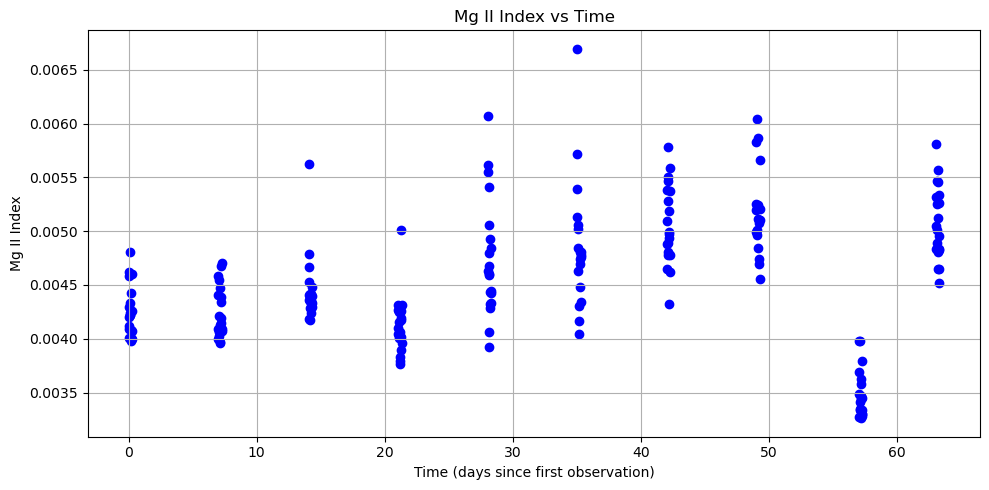

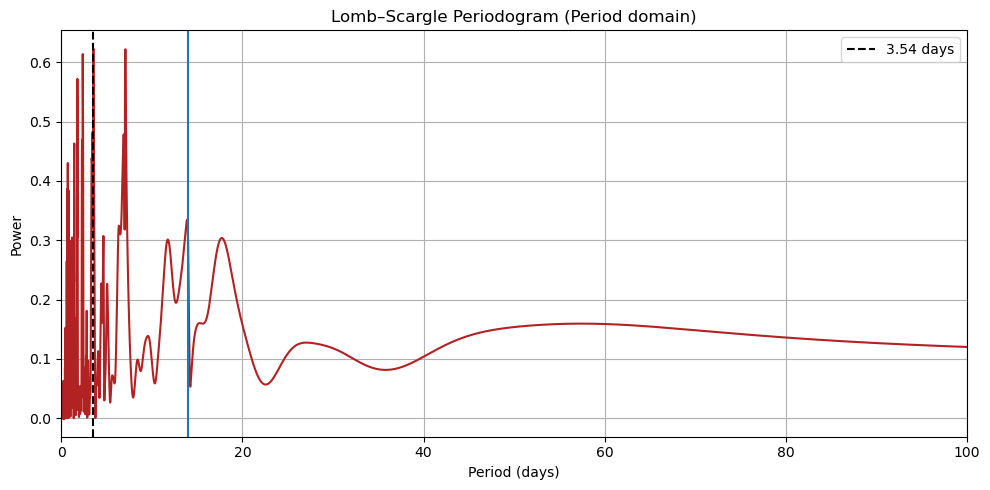

In [43]:
y_err = np.array(mgii_err, float)

frequency, power = LombScargle(t_days, y_err).autopower(samples_per_peak=5000)

best_freq = frequency[np.argmax(power)]
best_period = 1 / best_freq   # already in DAYS

print("Best period (days):", best_period)

# -------------------------------------------------------
# 3. Plot Mg II vs Time
# -------------------------------------------------------
plt.figure(figsize=(10,5))
plt.scatter(t_days, y_err, color='blue')
plt.xlabel("Time (days since first observation)")
plt.ylabel("Mg II Index")
plt.title("Mg II Index vs Time")
plt.grid(True)
plt.tight_layout()
plt.show()



# -------------------------------------------------------
# 5. Plot LS: Power vs Period
# -------------------------------------------------------
period = 1 / frequency

plt.figure(figsize=(10,5))
plt.plot(period, power, 'firebrick')
plt.axvline(best_period, color='black', linestyle='--', label=f"{best_period:.2f} days")
plt.xlabel("Period (days)")
plt.xlim(0, 100)   # You can expand
plt.ylabel("Power")
plt.title("Lomb–Scargle Periodogram (Period domain)")
plt.grid(True)
plt.axvline(14)
plt.legend()
plt.tight_layout()
plt.show()